# VLM Benchmark: GLM-4.6V vs GLM-4.1V-9B on Catan Board Understanding

Interactive benchmark comparing two vision-language models on their ability to understand Catan board states from rendered images.

- **GLM-4.6V** (`z-ai/glm-4.6v`) -- 128K context, current project choice
- **GLM-4.1V-9B-Thinking** (`thudm/glm-4.1v-9b-thinking`) -- 64K context, RL-enhanced reasoning
- **Gemini 2.5 Flash** (`google/gemini-2.5-flash`) -- Judge model

All API calls via OpenRouter.

## 1. Setup

In [13]:
import sys
import os
import random

# Ensure project root is on path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from IPython.display import display, Image as IPImage, Markdown, HTML
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

from engine.models.player import Color, Player
from engine.models.enums import ActionType
from engine.game import Game
from playground.board_renderer import CatanBoardRenderer
from playground.screenshot_board import FrontendScreenshotter
from playground.openrouter_client import (
    MODELS, query_vlm, query_both_vlms, judge_responses, query_text
)
from cle.env.observation_formatter import (
    CatanObservationFormatter, create_observation_from_state
)

pil_renderer = CatanBoardRenderer()
formatter = CatanObservationFormatter()

print(f"Models:")
for k, v in MODELS.items():
    print(f"  {k}: {v}")
print(f"\nOpenRouter key: {'set' if os.getenv('OPENROUTER_API_KEY') else 'MISSING'}")

Models:
  glm_4_6v: z-ai/glm-4.6v
  glm_4_1v: thudm/glm-4.1v-9b-thinking
  gemini_judge: google/gemini-2.5-flash

OpenRouter key: set


### Start Frontend Renderer

Boots the Flask backend, Vite dev server, and headless Chromium to screenshot the React board with Colonist assets. Skips servers already running. Set `USE_FRONTEND = False` to fall back to PIL.

In [ ]:
USE_FRONTEND = True  # Set False to fall back to PIL renderer

screenshotter = None
if USE_FRONTEND:
    screenshotter = FrontendScreenshotter(headless=True)
    await screenshotter.start()
    print("Frontend screenshotter ready.")
else:
    print("Using PIL renderer (no frontend).")

## 2. Generate Board State

Create a game, advance it, render the board inline.

In [ ]:
class SafeRandomPlayer(Player):
    """Random player that skips trade meta-actions."""
    def decide(self, game, playable_actions):
        safe = [a for a in playable_actions if not (
            a.action_type == ActionType.OFFER_TRADE and isinstance(a.value, str)
        )]
        if not safe:
            safe = playable_actions
        return random.choice(safe)


def make_game(seed=42, target_ticks=60):
    """Create and advance a game to get an interesting board state."""
    players = [SafeRandomPlayer(c) for c in [Color.RED, Color.BLUE, Color.WHITE, Color.ORANGE]]
    game = Game(players, seed=seed)
    for _ in range(target_ticks):
        if game.winning_color():
            break
        try:
            game.play_tick()
        except (ValueError, Exception):
            pass
    return game


def render_board(game):
    """Render board to PNG bytes using frontend screenshotter or PIL fallback."""
    if screenshotter is not None:
        return screenshotter.screenshot(game)
    return pil_renderer.render_to_bytes(game.state)


def show_board(game, player_color=Color.RED):
    """Render and display board inline, return PNG bytes."""
    img_bytes = render_board(game)
    display(IPImage(data=img_bytes, width=700 if screenshotter else 600))

    state = game.state
    print(f"Turn: {state.num_turns}")
    print(f"Buildings: {len(state.board.buildings)}")
    print(f"Roads: {len(state.board.roads) // 2}")
    if game.winning_color():
        print(f"Winner: {game.winning_color()}")
    return img_bytes


def get_text_context(game, player_color=Color.RED):
    """Get formatted text observation for a player."""
    obs = create_observation_from_state(game.state, player_color)
    formatted = formatter.format(obs)
    return formatted.raw_str

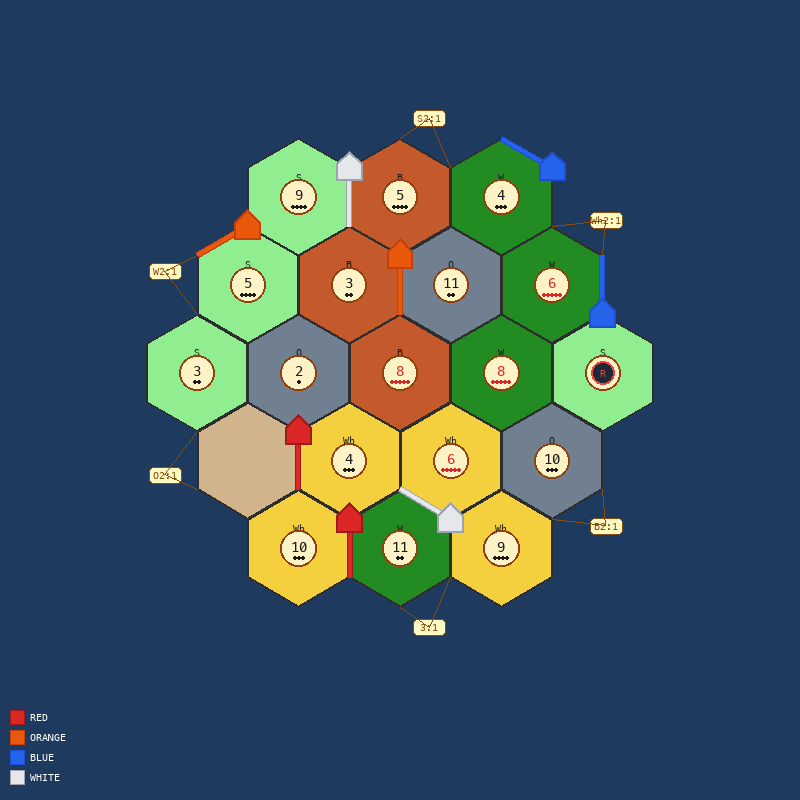

Turn: 31
Buildings: 8
Roads: 8


In [6]:
# Generate a mid-game scenario
game = make_game(seed=42, target_ticks=60)
img_bytes = show_board(game)

In [5]:
# Show the text context that accompanies the image
text_ctx = get_text_context(game, Color.RED)
print(text_ctx)

=== GAME STATE (Turn 31) ===

Phase: main_game
Your VP: 2/10

YOUR BUILDINGS:
  Settlements (2):
    - node 13 (-4, -1, 5): WHEAT(dice=4,pips=3), WOOD(dice=11,pips=2), WHEAT(dice=10,pips=3) | 8 pips
    - node 15 (-4, 2, 2): WHEAT(dice=4,pips=3), ORE(dice=2,pips=1) | 4 pips
  Roads (2): 2 connections

YOUR RESOURCES:
  WHEAT: 4
  ORE: 2
  Total: 6 cards

OPPONENTS:
  ORANGE: 2 VP (2 settlements, 0 cities, 2 roads, 10 resources)
  BLUE: 2 VP (2 settlements, 0 cities, 2 roads, 2 resources)
  WHITE: 2 VP (2 settlements, 0 cities, 2 roads, 7 resources)

VALID ACTIONS:
  END_TURN: 1 options
    0. Action(color=C.ORANGE, action_type=AT.END_TURN, value=None)
  ROLL: 1 options
    0. Action(color=C.ORANGE, action_type=AT.ROLL, value=None)


## 3. Quiz Both Models

Send the board image + a question to both GLM models side by side.

In [ ]:
def quiz(image_bytes, prompt, system_prompt="", show_prompt=True):
    """Send the same image+prompt to both models, display results side by side."""
    if show_prompt:
        display(Markdown(f"**Prompt:** {prompt}"))
        display(Markdown("---"))
    
    results = query_both_vlms(
        image_bytes, prompt, system_prompt=system_prompt
    )
    
    a = results['model_a']
    b = results['model_b']
    
    display(Markdown(f"### GLM-4.6V ({a['latency_ms']}ms)"))
    display(Markdown(a['content']))
    
    display(Markdown("---"))
    
    display(Markdown(f"### GLM-4.1V-9B-Thinking ({b['latency_ms']}ms)"))
    display(Markdown(b['content']))
    
    return results

### Task 1: Board Comprehension

Can the model correctly identify what's on the board?

In [ ]:
comprehension_prompt = """Look at this Catan board image carefully. Answer these questions:

1. How many hex tiles are there? What resources do you see?
2. Which numbers appear to be the best (most likely to be rolled)?
3. How many settlements and cities can you count? Which colors?
4. Where is the robber placed? What resource does that tile produce?
5. Can you identify any ports? What trade ratios do they offer?

Be specific and factual."""

comp_results = quiz(img_bytes, comprehension_prompt)

### Task 2: Strategic Analysis

Can the model reason about Catan strategy from the image?

In [ ]:
strategy_prompt = f"""Analyze this Catan board position from RED's perspective.

Game context:
{text_ctx}

Provide:
1. POSITION ASSESSMENT: Who is winning and why? (1-2 sentences)
2. KEY THREATS: What are the biggest threats to RED? (1-2 sentences)
3. WIN PATH: What is RED's most likely path to 10 VP? (1-2 sentences)
4. CRITICAL RESOURCE: What resource is most important for RED right now and why?"""

strat_results = quiz(img_bytes, strategy_prompt)

### Task 3: Best Move Selection

Can the model pick a good action from the valid set?

In [ ]:
move_prompt = f"""You are advising the RED player in this Catan game.

Current game context:
{text_ctx}

Looking at the board image AND the game context above, what is the single best action 
for RED to take right now and why?

Consider: resource production, blocking opponents, victory point efficiency, 
longest road / largest army competition.

Format:
ACTION: <specific action from the valid actions list>
REASONING: <2-3 sentences explaining why>"""

move_results = quiz(img_bytes, move_prompt)

## 4. Custom Quiz

Type your own question to ask both models about the current board.

In [ ]:
# Edit this prompt and run the cell to quiz both models
custom_prompt = "What resources does the red player have good access to based on their settlement positions?"

custom_results = quiz(img_bytes, custom_prompt)

## 5. Gemini Judge

Have Gemini evaluate both responses on accuracy, completeness, strategic depth, and specificity.

In [ ]:
def extract_ground_truth(game, player_color=Color.RED):
    """Extract verifiable ground truth from engine state."""
    state = game.state
    board = state.board
    catan_map = board.map
    
    lines = []
    
    # Tile count and resources
    resource_counts = {}
    for coord, tile in catan_map.land_tiles.items():
        r = tile.resource or 'DESERT'
        resource_counts[r] = resource_counts.get(r, 0) + 1
    lines.append(f"Land tiles: {len(catan_map.land_tiles)}")
    lines.append(f"Resources: {dict(resource_counts)}")
    
    # Buildings per player
    from engine.models.enums import SETTLEMENT, CITY
    building_summary = {}
    for node_id, (color, btype) in board.buildings.items():
        key = color.value if hasattr(color, 'value') else str(color)
        if key not in building_summary:
            building_summary[key] = {'settlements': 0, 'cities': 0}
        if btype == SETTLEMENT:
            building_summary[key]['settlements'] += 1
        elif btype == CITY:
            building_summary[key]['cities'] += 1
    lines.append(f"Buildings: {building_summary}")
    
    # Roads per player
    road_counts = {}
    seen_edges = set()
    for (n1, n2), color in board.roads.items():
        edge = (min(n1, n2), max(n1, n2))
        if edge in seen_edges:
            continue
        seen_edges.add(edge)
        key = color.value if hasattr(color, 'value') else str(color)
        road_counts[key] = road_counts.get(key, 0) + 1
    lines.append(f"Roads: {road_counts}")
    
    # Robber
    robber = board.robber_coordinate
    robber_tile = catan_map.land_tiles.get(robber)
    if robber_tile:
        lines.append(f"Robber on: {robber_tile.resource or 'DESERT'} (number {robber_tile.number})")
    
    # Ports
    port_info = []
    for resource, nodes in catan_map.port_nodes.items():
        if resource is None:
            port_info.append(f"3:1 generic port (nodes {sorted(nodes)})")
        else:
            port_info.append(f"{resource} 2:1 port (nodes {sorted(nodes)})")
    lines.append(f"Ports: {'; '.join(port_info)}")
    
    # Best numbers
    numbers = [t.number for t in catan_map.land_tiles.values() if t.number]
    high_pips = [n for n in numbers if n in (6, 8)]
    lines.append(f"High-probability numbers (6/8): {len(high_pips)} tiles")
    
    return '\n'.join(lines)

In [ ]:
# Judge the comprehension task
ground_truth = extract_ground_truth(game)
print("Ground Truth:")
print(ground_truth)
print("\n" + "="*60 + "\n")

verdict = judge_responses(
    task_description="Board comprehension: identify tiles, numbers, settlements, robber, ports",
    response_a=comp_results['model_a']['content'],
    response_b=comp_results['model_b']['content'],
    ground_truth=ground_truth,
)

display(Markdown(f"### Judge Verdict: **{verdict.get('winner', '?')}**"))
display(Markdown(f"*{verdict.get('explanation', '')}*"))

# Score table
scores_df = pd.DataFrame({
    'Dimension': ['Accuracy', 'Completeness', 'Strategic Depth', 'Specificity'],
    'GLM-4.6V': [verdict['scores_a'].get(k, 0) for k in ['accuracy', 'completeness', 'strategic_depth', 'specificity']],
    'GLM-4.1V-9B': [verdict['scores_b'].get(k, 0) for k in ['accuracy', 'completeness', 'strategic_depth', 'specificity']],
})
scores_df['Delta'] = scores_df['GLM-4.6V'] - scores_df['GLM-4.1V-9B']
display(scores_df)

## 6. Batch Benchmark

Run multiple scenarios across different game phases for a statistically meaningful comparison.

In [ ]:
SCENARIOS = [
    # (seed, ticks, phase_label)
    (1, 10, "initial"),
    (2, 10, "initial"),
    (3, 30, "early"),
    (4, 30, "early"),
    (5, 60, "mid"),
    (6, 60, "mid"),
    (7, 100, "late"),
    (8, 100, "late"),
    (9, 45, "mid"),
    (10, 80, "late"),
]

TASK_PROMPTS = {
    "comprehension": """Look at this Catan board. Answer concisely:
1. How many settlements and cities total? Which colors?
2. Where is the robber?
3. Which player appears strongest and why?
4. Name 2 high-probability tiles (6 or 8) and their resources.""",
    
    "strategy": """Analyze this Catan board from {color}'s perspective.
Game context: {text_ctx}
1. Who is winning and why?
2. What is {color}'s best path to 10 VP?
3. What is the most important resource for {color} right now?""",
    
    "move": """You are the {color} player. Game context: {text_ctx}
What is the single best action right now? Answer in format:
ACTION: <action>
REASONING: <why>""",
}

In [ ]:
all_results = []

for seed, ticks, phase in SCENARIOS:
    print(f"\n{'='*60}")
    print(f"Scenario: seed={seed}, ticks={ticks}, phase={phase}")
    print(f"{'='*60}")

    game = make_game(seed=seed, target_ticks=ticks)
    img = render_board(game)

    # Pick a player to analyze
    player_color = game.state.colors[0]
    color_name = player_color.value if hasattr(player_color, 'value') else str(player_color)
    text_ctx = get_text_context(game, player_color)
    ground_truth = extract_ground_truth(game, player_color)

    for task_name, prompt_template in TASK_PROMPTS.items():
        prompt = prompt_template.format(color=color_name, text_ctx=text_ctx)
        print(f"  Task: {task_name}...", end=" ", flush=True)

        try:
            responses = query_both_vlms(img, prompt)

            verdict = judge_responses(
                task_description=f"{task_name} task for {phase}-game scenario",
                response_a=responses['model_a']['content'],
                response_b=responses['model_b']['content'],
                ground_truth=ground_truth if task_name == 'comprehension' else '',
            )

            result = {
                'seed': seed,
                'phase': phase,
                'task': task_name,
                'turn': game.state.num_turns,
                'winner': verdict.get('winner', '?'),
                'a_accuracy': verdict['scores_a'].get('accuracy', 0),
                'a_completeness': verdict['scores_a'].get('completeness', 0),
                'a_strategic': verdict['scores_a'].get('strategic_depth', 0),
                'a_specificity': verdict['scores_a'].get('specificity', 0),
                'b_accuracy': verdict['scores_b'].get('accuracy', 0),
                'b_completeness': verdict['scores_b'].get('completeness', 0),
                'b_strategic': verdict['scores_b'].get('strategic_depth', 0),
                'b_specificity': verdict['scores_b'].get('specificity', 0),
                'a_latency': responses['model_a']['latency_ms'],
                'b_latency': responses['model_b']['latency_ms'],
                'explanation': verdict.get('explanation', ''),
            }
            all_results.append(result)
            print(f"Winner: {result['winner']}")
        except Exception as e:
            print(f"ERROR: {e}")

print(f"\nCompleted {len(all_results)} evaluations.")

## 7. Results Summary

In [ ]:
if all_results:
    df = pd.DataFrame(all_results)
    
    # Overall scores
    a_cols = ['a_accuracy', 'a_completeness', 'a_strategic', 'a_specificity']
    b_cols = ['b_accuracy', 'b_completeness', 'b_strategic', 'b_specificity']
    
    df['a_total'] = df[a_cols].mean(axis=1)
    df['b_total'] = df[b_cols].mean(axis=1)
    
    display(Markdown("### Overall Scores"))
    overall = pd.DataFrame({
        'Model': ['GLM-4.6V', 'GLM-4.1V-9B'],
        'Avg Score': [df['a_total'].mean(), df['b_total'].mean()],
        'Avg Accuracy': [df['a_accuracy'].mean(), df['b_accuracy'].mean()],
        'Avg Completeness': [df['a_completeness'].mean(), df['b_completeness'].mean()],
        'Avg Strategic': [df['a_strategic'].mean(), df['b_strategic'].mean()],
        'Avg Specificity': [df['a_specificity'].mean(), df['b_specificity'].mean()],
        'Avg Latency (ms)': [df['a_latency'].mean(), df['b_latency'].mean()],
    })
    display(overall.round(2))
    
    # Win rate
    display(Markdown("### Win Rate"))
    wins = df['winner'].value_counts()
    display(wins)
    
    # By task type
    display(Markdown("### Scores by Task Type"))
    by_task = df.groupby('task')[['a_total', 'b_total']].mean().round(2)
    by_task.columns = ['GLM-4.6V', 'GLM-4.1V-9B']
    display(by_task)
    
    # By game phase
    display(Markdown("### Scores by Game Phase"))
    by_phase = df.groupby('phase')[['a_total', 'b_total']].mean().round(2)
    by_phase.columns = ['GLM-4.6V', 'GLM-4.1V-9B']
    display(by_phase)
    
    # Full results
    display(Markdown("### All Results"))
    display(df[['seed', 'phase', 'task', 'turn', 'winner', 'a_total', 'b_total', 'a_latency', 'b_latency']].round(2))
else:
    print("No results yet. Run the batch benchmark above first.")

## 8. Try Different Board States

Change the seed and tick count to generate different scenarios.

In [ ]:
# Try a different scenario
game = make_game(seed=123, target_ticks=40)
img_bytes = show_board(game)
text_ctx = get_text_context(game, Color.BLUE)

In [ ]:
# Quiz on the new board
results = quiz(img_bytes, "Describe what you see on this Catan board. Which player is in the best position and why?")

## 9. Cleanup

Stop the frontend screenshotter (kills browser, optionally kills servers we started).

In [ ]:
if screenshotter is not None:
    screenshotter.stop()
    print("Screenshotter stopped.")